In [1]:
#load data
import numpy as np

def load_data(num_disks):

    left_j0_base_pose_traj = np.load(f'./{num_disks}-disks/left_j0_base_pose_traj.npy')
    left_j1_base_pose_traj = np.load(f'./{num_disks}-disks/left_j1_base_pose_traj.npy')
    left_j2_base_pose_traj = np.load(f'./{num_disks}-disks/left_j2_base_pose_traj.npy')
    left_j0_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j0_tip_pose_traj.npy')
    left_j1_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j1_tip_pose_traj.npy')
    left_j2_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j2_tip_pose_traj.npy')

    right_j0_base_pose_traj = np.load(f'./{num_disks}-disks/right_j0_base_pose_traj.npy')
    right_j1_base_pose_traj = np.load(f'./{num_disks}-disks/right_j1_base_pose_traj.npy')
    right_j2_base_pose_traj = np.load(f'./{num_disks}-disks/right_j2_base_pose_traj.npy')
    right_j0_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j0_tip_pose_traj.npy')
    right_j1_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j1_tip_pose_traj.npy')
    right_j2_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j2_tip_pose_traj.npy')

    left_q0_traj = np.load(f'./{num_disks}-disks/left_q0_traj.npy')
    left_q1_traj = np.load(f'./{num_disks}-disks/left_q1_traj.npy')
    left_q2_traj = np.load(f'./{num_disks}-disks/left_q2_traj.npy')

    right_q0_traj = np.load(f'./{num_disks}-disks/right_q0_traj.npy')
    right_q1_traj = np.load(f'./{num_disks}-disks/right_q1_traj.npy')
    right_q2_traj = np.load(f'./{num_disks}-disks/right_q2_traj.npy')

    #return dictionary of arrays
    return {
        'left_j0_base_pose_traj': left_j0_base_pose_traj,
        'left_j1_base_pose_traj': left_j1_base_pose_traj,
        'left_j2_base_pose_traj': left_j2_base_pose_traj,
        'left_j0_tip_pose_traj': left_j0_tip_pose_traj,
        'left_j1_tip_pose_traj': left_j1_tip_pose_traj,
        'left_j2_tip_pose_traj': left_j2_tip_pose_traj,
        'right_j0_base_pose_traj': right_j0_base_pose_traj,
        'right_j1_base_pose_traj': right_j1_base_pose_traj,
        'right_j2_base_pose_traj': right_j2_base_pose_traj,
        'right_j0_tip_pose_traj': right_j0_tip_pose_traj,
        'right_j1_tip_pose_traj': right_j1_tip_pose_traj,
        'right_j2_tip_pose_traj': right_j2_tip_pose_traj,
        'left_q0_traj': left_q0_traj,
        'left_q1_traj': left_q1_traj,
        'left_q2_traj': left_q2_traj,
        'right_q0_traj': right_q0_traj,
        'right_q1_traj': right_q1_traj,
        'right_q2_traj': right_q2_traj
    }




In [2]:
baseline_num_disks = 64
baseline = load_data(64)
data_32 = load_data(32)
baseline = load_data(baseline_num_disks)
data_16 = load_data(16)
data_8 = load_data(8)
data_4 = load_data(4)
data_2 = load_data(2)



In [3]:
from scipy.spatial.transform import Rotation as R

def constant_curvature_forward_kine(u,v, num_disks):
    #use allen kinematics to calculate tip pose expressed in joint base frame, given joint angles
    phi = np.sqrt(u**2 + v**2)
    h = .225 #m, see params.yaml in baloo-mujoco-sim
    if phi < 1e-6:
        g = np.array(
            [
                [1 - v**2/2, u*v/2, v, v*h/2],
                [u*v/2, 1 - u**2/2, -u, -u*h/2],
                [-v, u, 1-phi**2/2, h - h*phi**2/6],
                [0, 0, 0, 1]
            ]
        )
    else:
        sigma = np.cos(phi) - 1
        vtilde = v/phi
        utilde = u/phi
        rhox = h*v/phi**2
        rhoy = -h*u/phi**2
        rho = np.sqrt(rhox**2 + rhoy**2)
        #g is pose of tip in base frame
        g = np.array(
            [
                [sigma * vtilde**2 + 1, -sigma*utilde*vtilde, vtilde*np.sin(phi), -rhox * sigma],
                [-sigma*utilde*vtilde, sigma*utilde**2 + 1, -utilde*np.sin(phi), -rhoy*sigma],
                [-vtilde*np.sin(phi), utilde*np.sin(phi), np.cos(phi), rho*np.sin(phi)],
                [0, 0, 0, 1]

            ]
        )

    position = g[:3,3]
    orientation = R.from_matrix(g[:3,:3])

    return position, orientation.as_quat()
    



In [4]:
#now generate tip pose in base frame based on CC for each joint
baseline['left_j0_fkcc_pos'] = []
baseline['left_j0_fkcc_quat'] = []
for u,v in baseline['left_q0_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['left_j0_fkcc_pos'].append(pos)
    baseline['left_j0_fkcc_quat'].append(quat)

baseline['left_j1_fkcc_pos'] = []
baseline['left_j1_fkcc_quat'] = []
for u,v in baseline['left_q1_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['left_j1_fkcc_pos'].append(pos)
    baseline['left_j1_fkcc_quat'].append(quat)

baseline['left_j2_fkcc_pos'] = []
baseline['left_j2_fkcc_quat'] = []
for u,v in baseline['left_q2_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['left_j2_fkcc_pos'].append(pos)
    baseline['left_j2_fkcc_quat'].append(quat)

baseline['right_j0_fkcc_pos'] = []
baseline['right_j0_fkcc_quat'] = []
for u,v in baseline['right_q0_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['right_j0_fkcc_pos'].append(pos)
    baseline['right_j0_fkcc_quat'].append(quat)

baseline['right_j1_fkcc_pos'] = []
baseline['right_j1_fkcc_quat'] = []
for u,v in baseline['right_q1_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['right_j1_fkcc_pos'].append(pos)
    baseline['right_j1_fkcc_quat'].append(quat)

baseline['right_j2_fkcc_pos'] = []
baseline['right_j2_fkcc_quat'] = []
for u,v in baseline['right_q2_traj']:
    pos, quat = constant_curvature_forward_kine(u,v, baseline_num_disks)
    baseline['right_j2_fkcc_pos'].append(pos)
    baseline['right_j2_fkcc_quat'].append(quat)
    

I now have the constant curvature predicted pose and orientation of the tip of each joint in the joint base frame. I need to compare these to the actual pose and orientation of the tip of each joint in the base frame. 

Using the pose data above, I have the actual tip and base poses of each joint in the world frame. So I need to use these to calculate the actual transformation between the base and the tip.

This is the math I need to do:

I have data for the following (using monogram notation from drake)[https://manipulation.csail.mit.edu/pick.html#monogram]:

${}^{W}p^{B}_{W}, {}^{W}p^{T}_{W}, {}^{W}R^{B}, {}^{W}R^{T}$


where ${}^{W}p^{B}_{W}$ is the position of base relative to world and expressed in world. ${}^{W}R^{T}$ is the orientation of the tip frame relative to world frame.

I want to calculate the following:

${}^{B}p^{T}_{B}, {}^{B}R^{T}$, which is another way of saying I want ${}^{B}T^{T}$, the transformation from tip to base, expressed in the base frame. This transform is what I want to compare to $g$ above with the constant curvature assumption.

To do this, I need to calculate the following:

${}^{B}p^{T}_{B} = {}^{B}R^{W}({}^{W}p^{T}_{W} - {}^{W}p^{B}_{W}) = {}^{W}p^{T}_{B} + {}^{B}p^{W}_{B}$

${}^{B}R^{T} = ({}^{W}R^{B})^{-1} *  {}^{W}R^{T}$


# Error Between Contant Curvature and True Tip Pose

In [5]:
def get_base_to_tip_pose(base_traj, tip_traj, h, num_disks):
    base_to_tip_position = []
    base_to_tip_orientation = []
    #need disk height to offset to tip and base positions, not the centroid of the disk geoms.
    disk_height = h/(num_disks + num_disks - 1)

    for base, tip in zip(base_traj, tip_traj):
        p_WB_W = base[:3]
        p_WT_W = tip[:3]
        base_xyzw = np.roll(base[3:], -1)
        R_WB = R.from_quat(base_xyzw)

        p_BT_B = R_WB.inv().apply(p_WT_W - p_WB_W)
        p_bB_B = p_Tt_T = np.array([0,0,disk_height/2])

        base_xyzw = np.roll(base[3:], -1)
        tip_xyzw = np.roll(tip[3:], -1)
        R_WB = R.from_quat(base_xyzw)
        R_WT = R.from_quat(tip_xyzw)
        R_BT = R_WB.inv() * R_WT
        base_to_tip_orientation.append(R_BT.as_quat())

        p_Tt_B = R_BT.apply(p_Tt_T)

        p_bt_B = p_bB_B + p_BT_B + p_Tt_B
        base_to_tip_position.append(p_bt_B)

    return base_to_tip_position, base_to_tip_orientation

In [6]:
#first three are position, last four are quaternion in wxyz
print(baseline['left_j0_base_pose_traj'][0])

[-0.425       0.36673611  1.48286457  0.51327997 -0.76817776 -0.31818965
 -0.21260752]


In [7]:
#relative rotation between base and tip frames over trajectory
baseline['left_j0_p_BT_B'], baseline['left_j0_R_BT'] = get_base_to_tip_pose(baseline['left_j0_base_pose_traj'], baseline['left_j0_tip_pose_traj'], .225, baseline_num_disks)
baseline['left_j1_p_BT_B'], baseline['left_j1_R_BT'] = get_base_to_tip_pose(baseline['left_j1_base_pose_traj'], baseline['left_j1_tip_pose_traj'], .225, baseline_num_disks)
baseline['left_j2_p_BT_B'], baseline['left_j2_R_BT'] = get_base_to_tip_pose(baseline['left_j2_base_pose_traj'], baseline['left_j2_tip_pose_traj'], .225, baseline_num_disks)

baseline['right_j0_p_BT_B'], baseline['right_j0_R_BT'] = get_base_to_tip_pose(baseline['right_j0_base_pose_traj'], baseline['right_j0_tip_pose_traj'], .225, baseline_num_disks)
baseline['right_j1_p_BT_B'], baseline['right_j1_R_BT'] = get_base_to_tip_pose(baseline['right_j1_base_pose_traj'], baseline['right_j1_tip_pose_traj'], .225, baseline_num_disks)
baseline['right_j2_p_BT_B'], baseline['right_j2_R_BT'] = get_base_to_tip_pose(baseline['right_j2_base_pose_traj'], baseline['right_j2_tip_pose_traj'], .225, baseline_num_disks)

In [8]:
def get_rotation_error(quat1_traj, quat2_traj):
    error = []
    for fkcc, actual in zip(quat1_traj, quat2_traj):
        R_fkcc = R.from_quat(fkcc)
        R_actual = R.from_quat(actual)
        R_err = R_fkcc.inv() * R_actual
        error.append(R_err.magnitude())

    return error

def get_position_error(pos1_traj, pos2_traj):
    error = []
    for pos1, pos2 in zip(pos1_traj, pos2_traj):
        error.append(np.linalg.norm(pos1 - pos2))
    return error


In [9]:
#now get rotation error between fkcc and actual from mujoco
baseline['left_j0_R_err'] = get_rotation_error(baseline['left_j0_fkcc_quat'], baseline['left_j0_R_BT'])
baseline['left_j1_R_err'] = get_rotation_error(baseline['left_j1_fkcc_quat'], baseline['left_j1_R_BT'])
baseline['left_j2_R_err'] = get_rotation_error(baseline['left_j2_fkcc_quat'], baseline['left_j2_R_BT'])

baseline['left_j0_p_err'] = get_position_error(baseline['left_j0_fkcc_pos'], baseline['left_j0_p_BT_B'])
baseline['left_j1_p_err'] = get_position_error(baseline['left_j1_fkcc_pos'], baseline['left_j1_p_BT_B'])
baseline['left_j2_p_err'] = get_position_error(baseline['left_j2_fkcc_pos'], baseline['left_j2_p_BT_B'])

baseline['right_j0_R_err'] = get_rotation_error(baseline['right_j0_fkcc_quat'], baseline['right_j0_R_BT'])
baseline['right_j1_R_err'] = get_rotation_error(baseline['right_j1_fkcc_quat'], baseline['right_j1_R_BT'])
baseline['right_j2_R_err'] = get_rotation_error(baseline['right_j2_fkcc_quat'], baseline['right_j2_R_BT'])

baseline['right_j0_p_err'] = get_position_error(baseline['right_j0_fkcc_pos'], baseline['right_j0_p_BT_B'])
baseline['right_j1_p_err'] = get_position_error(baseline['right_j1_fkcc_pos'], baseline['right_j1_p_BT_B'])
baseline['right_j2_p_err'] = get_position_error(baseline['right_j2_fkcc_pos'], baseline['right_j2_p_BT_B'])

In [10]:
baseline['all_p_err'] = baseline['left_j0_p_err'] + baseline['left_j1_p_err'] + baseline['left_j2_p_err'] + baseline['right_j0_p_err'] + baseline['right_j1_p_err'] + baseline['right_j2_p_err']
baseline['all_R_err'] = baseline['left_j0_R_err'] + baseline['left_j1_R_err'] + baseline['left_j2_R_err'] + baseline['right_j0_R_err'] + baseline['right_j1_R_err'] + baseline['right_j2_R_err']    

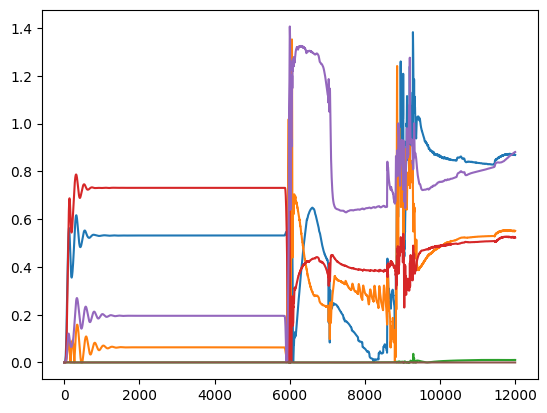

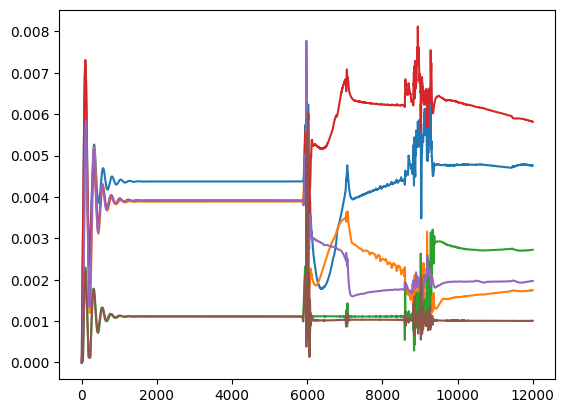

In [11]:
#plot showing rotation error of constant curvature vs mujoco 'real'
import matplotlib.pyplot as plt 
plt.plot(np.degrees(baseline['left_j0_R_err']))
plt.plot(np.degrees(baseline['left_j1_R_err']))
plt.plot(np.degrees(baseline['left_j2_R_err']))

plt.plot(np.degrees(baseline['right_j0_R_err']))
plt.plot(np.degrees(baseline['right_j1_R_err']))
plt.plot(np.degrees(baseline['right_j2_R_err']))

plt.figure()
plt.plot(baseline['left_j0_p_err'])
plt.plot(baseline['left_j1_p_err'])
plt.plot(baseline['left_j2_p_err'])

plt.plot(baseline['right_j0_p_err'])
plt.plot(baseline['right_j1_p_err'])
plt.plot(baseline['right_j2_p_err'])


What am I comparing. I'm saying that constant curvature is wrong under loaded conditions. See how wrong it is over a test trajecotory?

But then the disks can actually do a better job of predicting the real continuum pose of the tip (as defined by lots of disks).



# 32 disks vs baseline

In [12]:
data_32['left_j0_p_BT_B'], data_32['left_j0_R_BT'] = get_base_to_tip_pose(data_32['left_j0_base_pose_traj'], data_32['left_j0_tip_pose_traj'], .225, 32)
data_32['left_j1_p_BT_B'], data_32['left_j1_R_BT'] = get_base_to_tip_pose(data_32['left_j1_base_pose_traj'], data_32['left_j1_tip_pose_traj'], .225, 32)
data_32['left_j2_p_BT_B'], data_32['left_j2_R_BT'] = get_base_to_tip_pose(data_32['left_j2_base_pose_traj'], data_32['left_j2_tip_pose_traj'], .225, 32)

data_32['right_j0_p_BT_B'], data_32['right_j0_R_BT'] = get_base_to_tip_pose(data_32['right_j0_base_pose_traj'], data_32['right_j0_tip_pose_traj'], .225, 32)
data_32['right_j1_p_BT_B'], data_32['right_j1_R_BT'] = get_base_to_tip_pose(data_32['right_j1_base_pose_traj'], data_32['right_j1_tip_pose_traj'], .225, 32)
data_32['right_j2_p_BT_B'], data_32['right_j2_R_BT'] = get_base_to_tip_pose(data_32['right_j2_base_pose_traj'], data_32['right_j2_tip_pose_traj'], .225, 32)

data_32['left_j0_R_err'] = get_rotation_error(baseline['left_j0_R_BT'], data_32['left_j0_R_BT'])
data_32['left_j1_R_err'] = get_rotation_error(baseline['left_j1_R_BT'], data_32['left_j1_R_BT'])
data_32['left_j2_R_err'] = get_rotation_error(baseline['left_j2_R_BT'], data_32['left_j2_R_BT'])

data_32['left_j0_p_err'] = get_position_error(baseline['left_j0_p_BT_B'], data_32['left_j0_p_BT_B'])
data_32['left_j1_p_err'] = get_position_error(baseline['left_j1_p_BT_B'], data_32['left_j1_p_BT_B'])
data_32['left_j2_p_err'] = get_position_error(baseline['left_j2_p_BT_B'], data_32['left_j2_p_BT_B'])

data_32['right_j0_R_err'] = get_rotation_error(baseline['right_j0_R_BT'], data_32['right_j0_R_BT'])
data_32['right_j1_R_err'] = get_rotation_error(baseline['right_j1_R_BT'], data_32['right_j1_R_BT'])
data_32['right_j2_R_err'] = get_rotation_error(baseline['right_j2_R_BT'], data_32['right_j2_R_BT'])

data_32['right_j0_p_err'] = get_position_error(baseline['right_j0_p_BT_B'], data_32['right_j0_p_BT_B'])
data_32['right_j1_p_err'] = get_position_error(baseline['right_j1_p_BT_B'], data_32['right_j1_p_BT_B'])
data_32['right_j2_p_err'] = get_position_error(baseline['right_j2_p_BT_B'], data_32['right_j2_p_BT_B'])

data_32['all_p_err'] = data_32['left_j0_p_err'] + data_32['left_j1_p_err'] + data_32['left_j2_p_err'] + data_32['right_j0_p_err'] + data_32['right_j1_p_err'] + data_32['right_j2_p_err']
data_32['all_R_err'] = data_32['left_j0_R_err'] + data_32['left_j1_R_err'] + data_32['left_j2_R_err'] + data_32['right_j0_R_err'] + data_32['right_j1_R_err'] + data_32['right_j2_R_err']

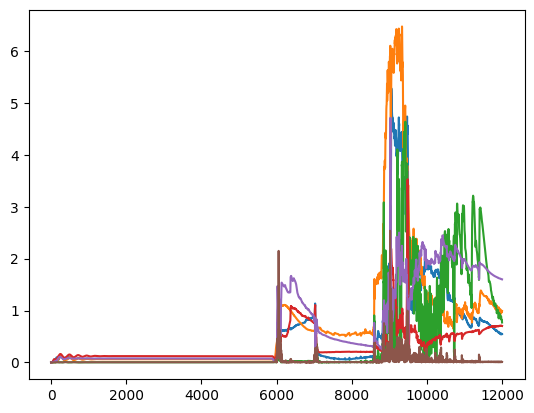

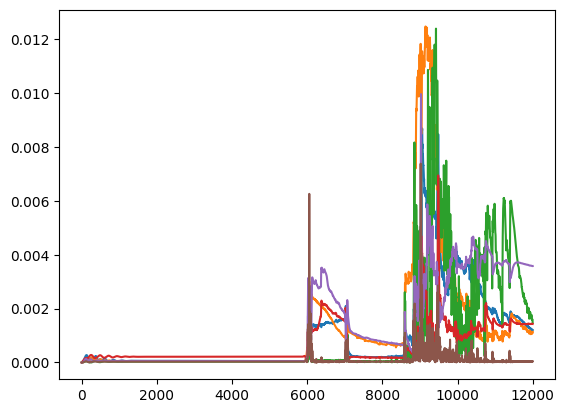

In [13]:
#plot error over time for orientation of baseline vs 32 disk
plt.figure()
plt.plot(np.degrees(data_32['left_j0_R_err']))
plt.plot(np.degrees(data_32['left_j1_R_err']))
plt.plot(np.degrees(data_32['left_j2_R_err']))

plt.plot(np.degrees(data_32['right_j0_R_err']))
plt.plot(np.degrees(data_32['right_j1_R_err']))
plt.plot(np.degrees(data_32['right_j2_R_err']))

plt.figure()
plt.plot(data_32['left_j0_p_err'])
plt.plot(data_32['left_j1_p_err'])
plt.plot(data_32['left_j2_p_err'])

plt.plot(data_32['right_j0_p_err'])
plt.plot(data_32['right_j1_p_err'])
plt.plot(data_32['right_j2_p_err'])

# 16 disks vs baseline

In [14]:
data_16['left_j0_p_BT_B'], data_16['left_j0_R_BT'] = get_base_to_tip_pose(data_16['left_j0_base_pose_traj'], data_16['left_j0_tip_pose_traj'], .225, 16)
data_16['left_j1_p_BT_B'], data_16['left_j1_R_BT'] = get_base_to_tip_pose(data_16['left_j1_base_pose_traj'], data_16['left_j1_tip_pose_traj'], .225, 16)
data_16['left_j2_p_BT_B'], data_16['left_j2_R_BT'] = get_base_to_tip_pose(data_16['left_j2_base_pose_traj'], data_16['left_j2_tip_pose_traj'], .225, 16)

data_16['right_j0_p_BT_B'], data_16['right_j0_R_BT'] = get_base_to_tip_pose(data_16['right_j0_base_pose_traj'], data_16['right_j0_tip_pose_traj'], .225, 16)
data_16['right_j1_p_BT_B'], data_16['right_j1_R_BT'] = get_base_to_tip_pose(data_16['right_j1_base_pose_traj'], data_16['right_j1_tip_pose_traj'], .225, 16)
data_16['right_j2_p_BT_B'], data_16['right_j2_R_BT'] = get_base_to_tip_pose(data_16['right_j2_base_pose_traj'], data_16['right_j2_tip_pose_traj'], .225, 16)

data_16['left_j0_R_err'] = get_rotation_error(baseline['left_j0_R_BT'], data_16['left_j0_R_BT'])
data_16['left_j1_R_err'] = get_rotation_error(baseline['left_j1_R_BT'], data_16['left_j1_R_BT'])
data_16['left_j2_R_err'] = get_rotation_error(baseline['left_j2_R_BT'], data_16['left_j2_R_BT'])

data_16['left_j0_p_err'] = get_position_error(baseline['left_j0_p_BT_B'], data_16['left_j0_p_BT_B'])
data_16['left_j1_p_err'] = get_position_error(baseline['left_j1_p_BT_B'], data_16['left_j1_p_BT_B'])
data_16['left_j2_p_err'] = get_position_error(baseline['left_j2_p_BT_B'], data_16['left_j2_p_BT_B'])

data_16['right_j0_R_err'] = get_rotation_error(baseline['right_j0_R_BT'], data_16['right_j0_R_BT'])
data_16['right_j1_R_err'] = get_rotation_error(baseline['right_j1_R_BT'], data_16['right_j1_R_BT'])
data_16['right_j2_R_err'] = get_rotation_error(baseline['right_j2_R_BT'], data_16['right_j2_R_BT'])

data_16['right_j0_p_err'] = get_position_error(baseline['right_j0_p_BT_B'], data_16['right_j0_p_BT_B'])
data_16['right_j1_p_err'] = get_position_error(baseline['right_j1_p_BT_B'], data_16['right_j1_p_BT_B'])
data_16['right_j2_p_err'] = get_position_error(baseline['right_j2_p_BT_B'], data_16['right_j2_p_BT_B'])

data_16['all_p_err'] = data_16['left_j0_p_err'] + data_16['left_j1_p_err'] + data_16['left_j2_p_err'] + data_16['right_j0_p_err'] + data_16['right_j1_p_err'] + data_16['right_j2_p_err']
data_16['all_R_err'] = data_16['left_j0_R_err'] + data_16['left_j1_R_err'] + data_16['left_j2_R_err'] + data_16['right_j0_R_err'] + data_16['right_j1_R_err'] + data_16['right_j2_R_err']


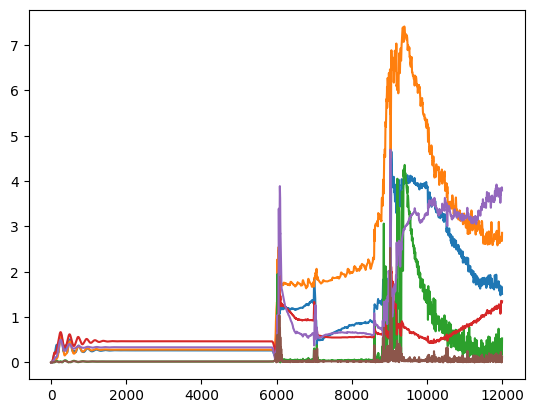

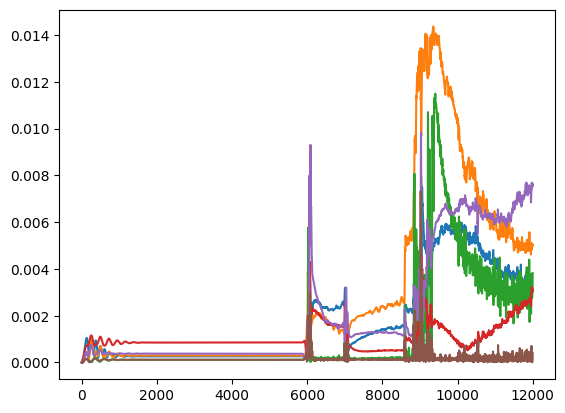

In [15]:
#plot error over time for orientation of baseline vs 32 disk
plt.figure()
plt.plot(np.degrees(data_16['left_j0_R_err']))
plt.plot(np.degrees(data_16['left_j1_R_err']))
plt.plot(np.degrees(data_16['left_j2_R_err']))

plt.plot(np.degrees(data_16['right_j0_R_err']))
plt.plot(np.degrees(data_16['right_j1_R_err']))
plt.plot(np.degrees(data_16['right_j2_R_err']))

plt.figure()
plt.plot(data_16['left_j0_p_err'])
plt.plot(data_16['left_j1_p_err'])
plt.plot(data_16['left_j2_p_err'])

plt.plot(data_16['right_j0_p_err'])
plt.plot(data_16['right_j1_p_err'])
plt.plot(data_16['right_j2_p_err'])

# 8 disks vs baseline

In [16]:
data_8['left_j0_p_BT_B'], data_8['left_j0_R_BT'] = get_base_to_tip_pose(data_8['left_j0_base_pose_traj'], data_8['left_j0_tip_pose_traj'], .225, 8)
data_8['left_j1_p_BT_B'], data_8['left_j1_R_BT'] = get_base_to_tip_pose(data_8['left_j1_base_pose_traj'], data_8['left_j1_tip_pose_traj'], .225, 8)
data_8['left_j2_p_BT_B'], data_8['left_j2_R_BT'] = get_base_to_tip_pose(data_8['left_j2_base_pose_traj'], data_8['left_j2_tip_pose_traj'], .225, 8)

data_8['right_j0_p_BT_B'], data_8['right_j0_R_BT'] = get_base_to_tip_pose(data_8['right_j0_base_pose_traj'], data_8['right_j0_tip_pose_traj'], .225, 8)
data_8['right_j1_p_BT_B'], data_8['right_j1_R_BT'] = get_base_to_tip_pose(data_8['right_j1_base_pose_traj'], data_8['right_j1_tip_pose_traj'], .225, 8)
data_8['right_j2_p_BT_B'], data_8['right_j2_R_BT'] = get_base_to_tip_pose(data_8['right_j2_base_pose_traj'], data_8['right_j2_tip_pose_traj'], .225, 8)

data_8['left_j0_R_err'] = get_rotation_error(baseline['left_j0_R_BT'], data_8['left_j0_R_BT'])
data_8['left_j1_R_err'] = get_rotation_error(baseline['left_j1_R_BT'], data_8['left_j1_R_BT'])
data_8['left_j2_R_err'] = get_rotation_error(baseline['left_j2_R_BT'], data_8['left_j2_R_BT'])

data_8['left_j0_p_err'] = get_position_error(baseline['left_j0_p_BT_B'], data_8['left_j0_p_BT_B'])
data_8['left_j1_p_err'] = get_position_error(baseline['left_j1_p_BT_B'], data_8['left_j1_p_BT_B'])
data_8['left_j2_p_err'] = get_position_error(baseline['left_j2_p_BT_B'], data_8['left_j2_p_BT_B'])

data_8['right_j0_R_err'] = get_rotation_error(baseline['right_j0_R_BT'], data_8['right_j0_R_BT'])
data_8['right_j1_R_err'] = get_rotation_error(baseline['right_j1_R_BT'], data_8['right_j1_R_BT'])
data_8['right_j2_R_err'] = get_rotation_error(baseline['right_j2_R_BT'], data_8['right_j2_R_BT'])

data_8['right_j0_p_err'] = get_position_error(baseline['right_j0_p_BT_B'], data_8['right_j0_p_BT_B'])
data_8['right_j1_p_err'] = get_position_error(baseline['right_j1_p_BT_B'], data_8['right_j1_p_BT_B'])
data_8['right_j2_p_err'] = get_position_error(baseline['right_j2_p_BT_B'], data_8['right_j2_p_BT_B'])

data_8['all_p_err'] = data_8['left_j0_p_err'] + data_8['left_j1_p_err'] + data_8['left_j2_p_err'] + data_8['right_j0_p_err'] + data_8['right_j1_p_err'] + data_8['right_j2_p_err']
data_8['all_R_err'] = data_8['left_j0_R_err'] + data_8['left_j1_R_err'] + data_8['left_j2_R_err'] + data_8['right_j0_R_err'] + data_8['right_j1_R_err'] + data_8['right_j2_R_err']

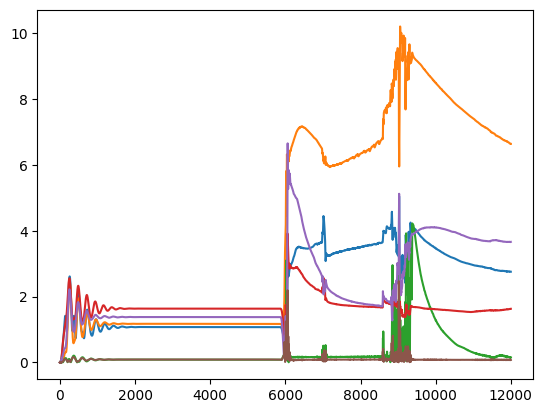

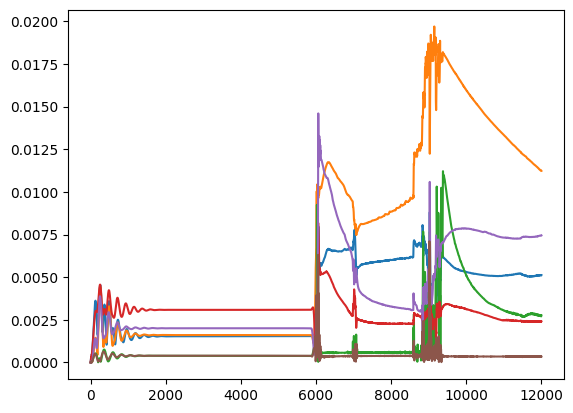

In [17]:
#plot error over time for orientation of baseline vs 32 disk
plt.figure()
plt.plot(np.degrees(data_8['left_j0_R_err']))
plt.plot(np.degrees(data_8['left_j1_R_err']))
plt.plot(np.degrees(data_8['left_j2_R_err']))

plt.plot(np.degrees(data_8['right_j0_R_err']))
plt.plot(np.degrees(data_8['right_j1_R_err']))
plt.plot(np.degrees(data_8['right_j2_R_err']))

plt.figure()
plt.plot(data_8['left_j0_p_err'])
plt.plot(data_8['left_j1_p_err'])
plt.plot(data_8['left_j2_p_err'])

plt.plot(data_8['right_j0_p_err'])
plt.plot(data_8['right_j1_p_err'])
plt.plot(data_8['right_j2_p_err'])

# 4 disks vs baseline

In [18]:
data_4['left_j0_p_BT_B'], data_4['left_j0_R_BT'] = get_base_to_tip_pose(data_4['left_j0_base_pose_traj'], data_4['left_j0_tip_pose_traj'], .225, 4)
data_4['left_j1_p_BT_B'], data_4['left_j1_R_BT'] = get_base_to_tip_pose(data_4['left_j1_base_pose_traj'], data_4['left_j1_tip_pose_traj'], .225, 4)
data_4['left_j2_p_BT_B'], data_4['left_j2_R_BT'] = get_base_to_tip_pose(data_4['left_j2_base_pose_traj'], data_4['left_j2_tip_pose_traj'], .225, 4)

data_4['right_j0_p_BT_B'], data_4['right_j0_R_BT'] = get_base_to_tip_pose(data_4['right_j0_base_pose_traj'], data_4['right_j0_tip_pose_traj'], .225, 4)
data_4['right_j1_p_BT_B'], data_4['right_j1_R_BT'] = get_base_to_tip_pose(data_4['right_j1_base_pose_traj'], data_4['right_j1_tip_pose_traj'], .225, 4)
data_4['right_j2_p_BT_B'], data_4['right_j2_R_BT'] = get_base_to_tip_pose(data_4['right_j2_base_pose_traj'], data_4['right_j2_tip_pose_traj'], .225, 4)

data_4['left_j0_R_err'] = get_rotation_error(baseline['left_j0_R_BT'], data_4['left_j0_R_BT'])
data_4['left_j1_R_err'] = get_rotation_error(baseline['left_j1_R_BT'], data_4['left_j1_R_BT'])
data_4['left_j2_R_err'] = get_rotation_error(baseline['left_j2_R_BT'], data_4['left_j2_R_BT'])

data_4['left_j0_p_err'] = get_position_error(baseline['left_j0_p_BT_B'], data_4['left_j0_p_BT_B'])
data_4['left_j1_p_err'] = get_position_error(baseline['left_j1_p_BT_B'], data_4['left_j1_p_BT_B'])
data_4['left_j2_p_err'] = get_position_error(baseline['left_j2_p_BT_B'], data_4['left_j2_p_BT_B'])

data_4['right_j0_R_err'] = get_rotation_error(baseline['right_j0_R_BT'], data_4['right_j0_R_BT'])
data_4['right_j1_R_err'] = get_rotation_error(baseline['right_j1_R_BT'], data_4['right_j1_R_BT'])
data_4['right_j2_R_err'] = get_rotation_error(baseline['right_j2_R_BT'], data_4['right_j2_R_BT'])

data_4['right_j0_p_err'] = get_position_error(baseline['right_j0_p_BT_B'], data_4['right_j0_p_BT_B'])
data_4['right_j1_p_err'] = get_position_error(baseline['right_j1_p_BT_B'], data_4['right_j1_p_BT_B'])
data_4['right_j2_p_err'] = get_position_error(baseline['right_j2_p_BT_B'], data_4['right_j2_p_BT_B'])

data_4['all_p_err'] = data_4['left_j0_p_err'] + data_4['left_j1_p_err'] + data_4['left_j2_p_err'] + data_4['right_j0_p_err'] + data_4['right_j1_p_err'] + data_4['right_j2_p_err']
data_4['all_R_err'] = data_4['left_j0_R_err'] + data_4['left_j1_R_err'] + data_4['left_j2_R_err'] + data_4['right_j0_R_err'] + data_4['right_j1_R_err'] + data_4['right_j2_R_err']

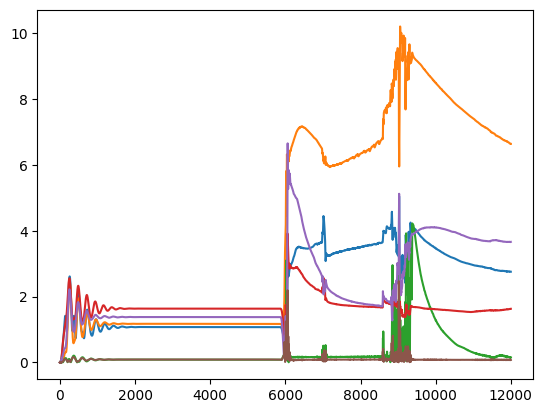

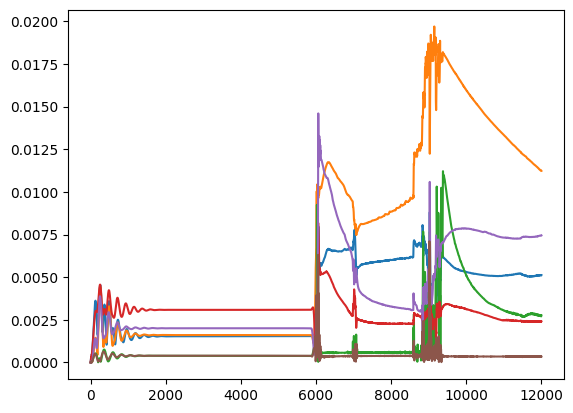

In [19]:
#plot error over time for orientation of baseline vs 32 disk
plt.figure()
plt.plot(np.degrees(data_8['left_j0_R_err']))
plt.plot(np.degrees(data_8['left_j1_R_err']))
plt.plot(np.degrees(data_8['left_j2_R_err']))

plt.plot(np.degrees(data_8['right_j0_R_err']))
plt.plot(np.degrees(data_8['right_j1_R_err']))
plt.plot(np.degrees(data_8['right_j2_R_err']))

plt.figure()
plt.plot(data_8['left_j0_p_err'])
plt.plot(data_8['left_j1_p_err'])
plt.plot(data_8['left_j2_p_err'])

plt.plot(data_8['right_j0_p_err'])
plt.plot(data_8['right_j1_p_err'])
plt.plot(data_8['right_j2_p_err'])

# 2 disks vs baseline

In [20]:
data_2['left_j0_p_BT_B'], data_2['left_j0_R_BT'] = get_base_to_tip_pose(data_2['left_j0_base_pose_traj'], data_2['left_j0_tip_pose_traj'], .225, 2)
data_2['left_j1_p_BT_B'], data_2['left_j1_R_BT'] = get_base_to_tip_pose(data_2['left_j1_base_pose_traj'], data_2['left_j1_tip_pose_traj'], .225, 2)
data_2['left_j2_p_BT_B'], data_2['left_j2_R_BT'] = get_base_to_tip_pose(data_2['left_j2_base_pose_traj'], data_2['left_j2_tip_pose_traj'], .225, 2)

data_2['right_j0_p_BT_B'], data_2['right_j0_R_BT'] = get_base_to_tip_pose(data_2['right_j0_base_pose_traj'], data_2['right_j0_tip_pose_traj'], .225, 2)
data_2['right_j1_p_BT_B'], data_2['right_j1_R_BT'] = get_base_to_tip_pose(data_2['right_j1_base_pose_traj'], data_2['right_j1_tip_pose_traj'], .225, 2)
data_2['right_j2_p_BT_B'], data_2['right_j2_R_BT'] = get_base_to_tip_pose(data_2['right_j2_base_pose_traj'], data_2['right_j2_tip_pose_traj'], .225, 2)

data_2['left_j0_R_err'] = get_rotation_error(baseline['left_j0_R_BT'], data_2['left_j0_R_BT'])
data_2['left_j1_R_err'] = get_rotation_error(baseline['left_j1_R_BT'], data_2['left_j1_R_BT'])
data_2['left_j2_R_err'] = get_rotation_error(baseline['left_j2_R_BT'], data_2['left_j2_R_BT'])

data_2['left_j0_p_err'] = get_position_error(baseline['left_j0_p_BT_B'], data_2['left_j0_p_BT_B'])
data_2['left_j1_p_err'] = get_position_error(baseline['left_j1_p_BT_B'], data_2['left_j1_p_BT_B'])
data_2['left_j2_p_err'] = get_position_error(baseline['left_j2_p_BT_B'], data_2['left_j2_p_BT_B'])

data_2['right_j0_R_err'] = get_rotation_error(baseline['right_j0_R_BT'], data_2['right_j0_R_BT'])
data_2['right_j1_R_err'] = get_rotation_error(baseline['right_j1_R_BT'], data_2['right_j1_R_BT'])
data_2['right_j2_R_err'] = get_rotation_error(baseline['right_j2_R_BT'], data_2['right_j2_R_BT'])

data_2['right_j0_p_err'] = get_position_error(baseline['right_j0_p_BT_B'], data_2['right_j0_p_BT_B'])
data_2['right_j1_p_err'] = get_position_error(baseline['right_j1_p_BT_B'], data_2['right_j1_p_BT_B'])
data_2['right_j2_p_err'] = get_position_error(baseline['right_j2_p_BT_B'], data_2['right_j2_p_BT_B'])

data_2['all_p_err'] = data_2['left_j0_p_err'] + data_2['left_j1_p_err'] + data_2['left_j2_p_err'] + data_2['right_j0_p_err'] + data_2['right_j1_p_err'] + data_2['right_j2_p_err']
data_2['all_R_err'] = data_2['left_j0_R_err'] + data_2['left_j1_R_err'] + data_2['left_j2_R_err'] + data_2['right_j0_R_err'] + data_2['right_j1_R_err'] + data_2['right_j2_R_err']

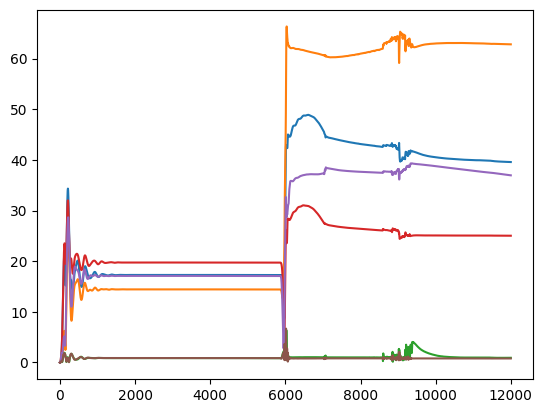

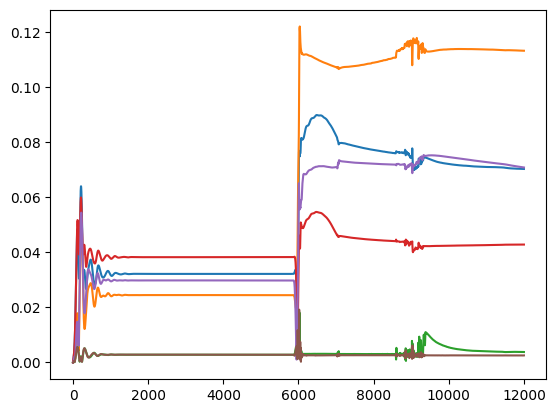

In [21]:
#plot error over time for orientation of baseline vs 32 disk
plt.figure()
plt.plot(np.degrees(data_2['left_j0_R_err']))
plt.plot(np.degrees(data_2['left_j1_R_err']))
plt.plot(np.degrees(data_2['left_j2_R_err']))

plt.plot(np.degrees(data_2['right_j0_R_err']))
plt.plot(np.degrees(data_2['right_j1_R_err']))
plt.plot(np.degrees(data_2['right_j2_R_err']))

plt.figure()
plt.plot(data_2['left_j0_p_err'])
plt.plot(data_2['left_j1_p_err'])
plt.plot(data_2['left_j2_p_err'])

plt.plot(data_2['right_j0_p_err'])
plt.plot(data_2['right_j1_p_err'])
plt.plot(data_2['right_j2_p_err'])

# Comparing all of these to the baseline

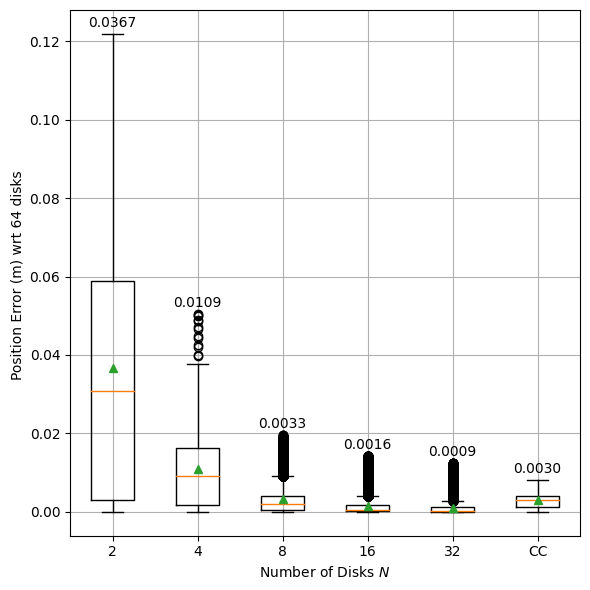

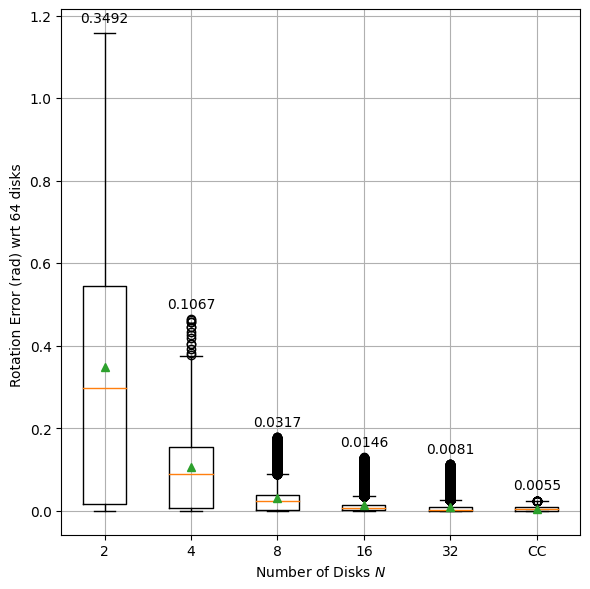

In [37]:
plt.figure(figsize=(6, 6))
p_errors = [
    data_2['all_p_err'],
    data_4['all_p_err'],
    data_8['all_p_err'],
    data_16['all_p_err'],
    data_32['all_p_err'],
    baseline['all_p_err'],
    ]
plt.boxplot([
    data_2['all_p_err'],
    data_4['all_p_err'],
    data_8['all_p_err'],
    data_16['all_p_err'],
    data_32['all_p_err'],
    baseline['all_p_err']
    ], showmeans=True)
plt.xticks([1,2,3,4,5,6], ['2', '4', '8', '16', '32', 'CC'])
plt.xlabel('Number of Disks $N$')
plt.ylabel('Position Error (m) wrt 64 disks ')
plt.grid()
for i, mean in enumerate([np.mean(error) for error in p_errors]):
    max = np.max(p_errors[i])
    plt.text(i + 1, max + 0.001, f'{mean:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("position_error_disks.png", dpi=300)

plt.figure(figsize=(6, 6))
R_errors = [
    data_2['all_R_err'],
    data_4['all_R_err'],
    data_8['all_R_err'],
    data_16['all_R_err'],
    data_32['all_R_err'],
    baseline['all_R_err']
    ]
plt.boxplot([
    data_2['all_R_err'],
    data_4['all_R_err'],
    data_8['all_R_err'],
    data_16['all_R_err'],
    data_32['all_R_err'],
    baseline['all_R_err']
    ], showfliers=True, showmeans=True)
plt.xticks([1,2,3,4,5,6], ['2', '4', '8', '16', '32', 'CC'])
plt.xlabel('Number of Disks $N$')
plt.ylabel('Rotation Error (rad) wrt 64 disks ')

for i, mean in enumerate([np.mean(error) for error in R_errors]):
    max = np.max(R_errors[i])
    plt.text(i + 1, max + 0.02, f'{mean:.4f}', ha='center', va='bottom')
plt.grid()
plt.tight_layout()
plt.savefig("rotation_error_disks.png", dpi=300)
plt.show()